# 1. Package and initial setting

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from SyntheticControlMethods import Synth

# Start year of the REDD project
REDD_project_start_year_dict = {875:  2009,
                                963:  2011,
                                977:  2009,
                                981:  2009,
                                1094: 2003,
                                1112: 2011,
                                1113: 2011,
                                1115: 2011,
                                1118: 2009,
                                1329: 2012,
                                1503: 2012,
                                1571: 2013,
                                1654: 2013,
                                1686: 2014,
                                1953: 2016,
                                2252: 2016,
                                2373: 2020,
                                2508: 2018,
                                2558: 2017,
                                2566: 2016,
                                904:  2008,
                                1650: 2010,
                                1389: 2013,
                                1390: 2014,
                                1391: 2013,
                                1392: 2013,
                                1395: 2013,
                                1396: 2014,
                                1399: 2013,
                                1400: 2013,
                                1566: 2013,
                                2290: 2015,
                                2723: 2019,
                                1359: 2009,
                                1541: 2012,
                                1398: 2014,
                                1311: 2007,
                                1674: 2012,
                                844:  2009,
                                944:  2008,
                                958:  2010,
                                985:  2008,
                                1067: 2010,
                                1218: 2011,
                                1360: 2010,
                                1799: 2017,
                                1882: 2013,
                                2278: 2018,
                                2502: 2017,
                                1201: 2012,
                                1325: 2012,
                                1897: 2017,
                                1900: 2016,
                                1532: 2012,
                                562: 2005,
                                612: 2010,
                                856: 2010,
                                902: 2011,
                                1202: 2009,
                                1689: 2015,
                                1748: 2015,
                                1775: 2015,
                                934: 2011,
                                2539: 2020,
                                1689: 2015,
                                2293: 2017,
                                2510: 2016,
                                2538: 2017
                             }

# Extract project id for project unit
def extract_project_id(project_unit):
    project_unit = str(project_unit)
    if '-' in project_unit:
        # Extract the part before '-'
        part_before_dash = project_unit.split('-')[0]
        try:
            # Convert to numerical value
            return int(part_before_dash)
        except ValueError:
            raise ValueError("The extracted part cannot be converted into a numerical value.")
    else:
        try:
            # Convert the entire string to a numerical value
            return int(project_unit)
        except ValueError:
            raise ValueError("The entire string cannot be converted to a numerical value.")

# 2. Build PSCM model

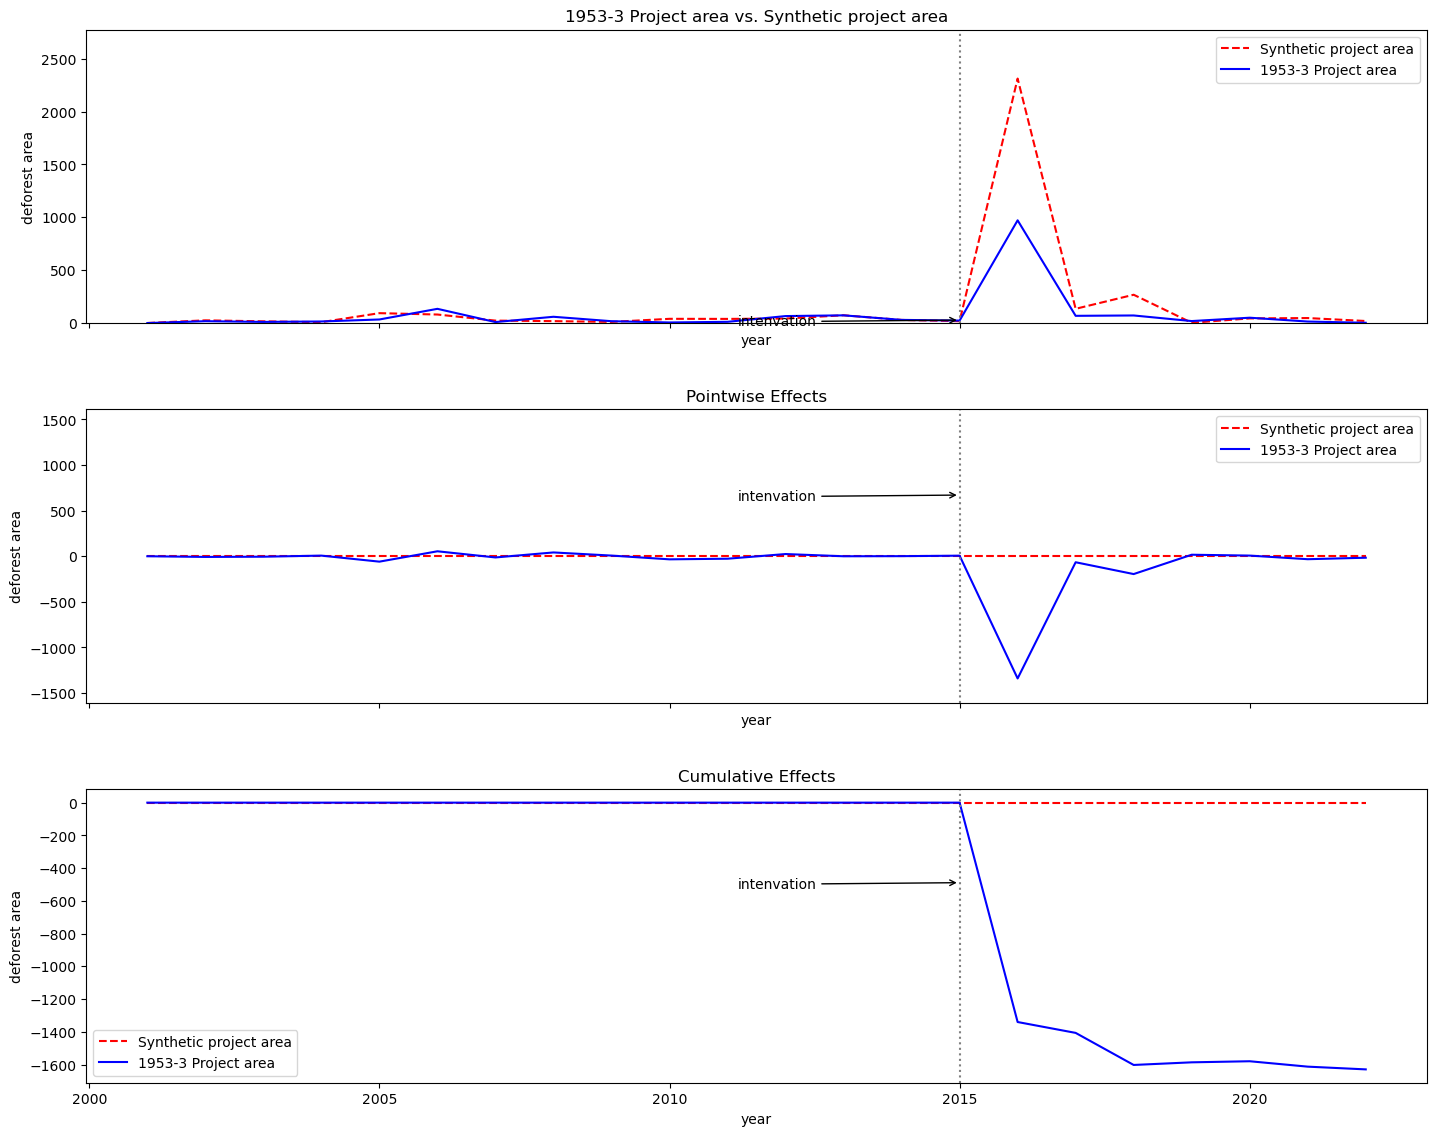

In [2]:
# Read data for target instance of target project unit, here we used project unit '1953-3' and instance 0 as an example
project_unit = '1953-3'
targer_instance = 0
table_path = 'Donor_data_of_all_instances_for_PSCM.xlsx'
df_of_all_instances = pd.read_excel(table_path, sheet_name = project_unit)
df_of_targer_instance = df_of_all_instances[df_of_all_instances['source_file'] == project_unit + '_SCM_data_df_' + str(targer_instance) + '.xlsx']

# Obtain the start year of the project
project_id = extract_project_id(project_unit)
start_year = REDD_project_start_year_dict.get(project_id)   

# Build PSCM model
PSCM_model = Synth(dataset = df_of_targer_instance, 
                   outcome_var = "deforest area",
                   id_var = "region",
                   time_var = "year",
                   treatment_period = start_year, 
                   treated_unit = "project area",
                   n_optim = 200, 
                   pen = "auto",
                   exclude_columns = ['source_file'],
                   random_seed = 0)

# Model visualization
PSCM_model.plot(["original", "pointwise", "cumulative"], 
                treated_label = project_unit + " Project area", 
                synth_label="Synthetic project area", 
                treatment_label="intenvation")

## Obtain quantitative results

In [3]:
# Obtain the rmspe of the synthetic controls
project_rmspe = PSCM_model.original_data.rmspe_df['pre_rmspe'][0]
project_rmspe

27.16379682135814

In [4]:
# Obtain the ids and weights of the synthetic controls
PSCM_model.original_data.weight_df

,Weight
donor 458,0.078746
donor 803,0.921254


In [ ]:
# Obatin normalized rmspe
# Obtain annual deforest area data of project area, and set it the 'project' column
project_rows = df_of_targer_instance[df_of_targer_instance['region'] == 'project area']
annual_deforest_df = project_rows[['year', 'deforest area']]
annual_deforest_df = annual_deforest_df.rename(columns={'deforest area': 'project'})

# Obtain the annual deforest area of synthetic controls from the PSCM_model as the 'synthetic' column
annual_deforest_df['synthetic'] = PSCM_model.original_data.synth_outcome.flatten().tolist()

# Obtain pre-REDD+ data
preREDD_df = annual_deforest_df[(annual_deforest_df['year'] >= 2001) & (annual_deforest_df['year'] < start_year)]

#Calculate the normalized rmspe
y_true = preREDD_df['project'].values
y_prec = preREDD_df['synthetic'].values
annual_normalized_rmspe = project_rmspe / (max(y_true)-min(y_true))
print('Normalized RMSPE:', annual_normalized_rmspe)

Normalized RMSPE: 0.20202139536931532


## Gernerate figures for comparison of annual and cumulative deforest bewteen project area and synthetic controls

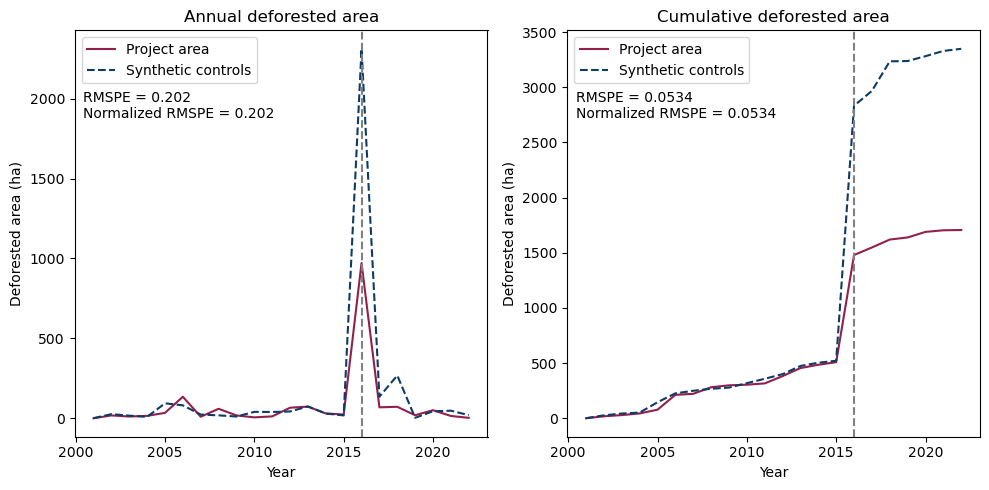

In [ ]:
# Obtain cumulativ deforest area data of the project area and synthetic controls 
cumulative_deforest_df = annual_deforest_df.copy()
cumulative_deforest_df.iloc[:, 1:] = annual_deforest_df.iloc[:, 1:].cumsum()
cumulative_deforest_df['cumulation difference'] = cumulative_deforest_df['project'] - cumulative_deforest_df['synthetic']

#Calculate the normalized rmspe of pre-REDD+ cumulative deforest area
preREDD_df = cumulative_deforest_df[(cumulative_deforest_df['year'] >= 2001) & (cumulative_deforest_df['year'] < start_year)]
y_true = preREDD_df['project'].values
y_prec = preREDD_df['synthetic'].values
cumulative_normalized_rmspe = project_rmspe / (max(y_true)-min(y_true))

# Draw figures for comparison of the annual and cumulative deforestation area between project area and synthetic controls
fig_row = 1
fig_column = 2
fig, axs = plt.subplots(fig_row, fig_column, figsize=(10, 5))

# Comparison of the annual deforestation area between project area and synthetic controls
axs[0].plot(annual_deforest_df['year'], annual_deforest_df['project'], label='Project area', color='#91204D')
axs[0].plot(annual_deforest_df['year'], annual_deforest_df['synthetic'], label='Synthetic controls', color='#0D3B66', linestyle='--')
axs[0].axvline(x=start_year, color='grey', linestyle='--')  # Draw a vertical line at x = start_year
axs[0].set_title('Annual deforested area')
axs[0].set_xlabel('Year')
axs[0].set_ylabel('Deforested area (ha)')
axs[0].text(0.02,0.85,f'RMSPE = {round(annual_normalized_rmspe,4)}\nNormalized RMSPE = {round(annual_normalized_rmspe,4)}',
            transform=axs[0].transAxes, verticalalignment = 'top')
axs[0].legend()

# Comparison of the cumulative deforestation area between project area and synthetic controls
axs[1].plot(cumulative_deforest_df['year'], cumulative_deforest_df['project'], label='Project area', color='#91204D')
axs[1].plot(cumulative_deforest_df['year'], cumulative_deforest_df['synthetic'], label='Synthetic controls', color='#0D3B66', linestyle='--')
axs[1].axvline(x=start_year, color='grey', linestyle='--')
axs[1].set_title('Cumulative deforested area')
axs[1].set_xlabel('Year')
axs[1].set_ylabel('Deforested area (ha)')
axs[1].text(0.02,0.85,f'RMSPE = {round(cumulative_normalized_rmspe,4)}\nNormalized RMSPE = {round(cumulative_normalized_rmspe,4)}',
            transform=axs[1].transAxes, verticalalignment = 'top')
axs[1].legend()

plt.tight_layout()
plt.show()
plt.close()

# 3. Placebo test

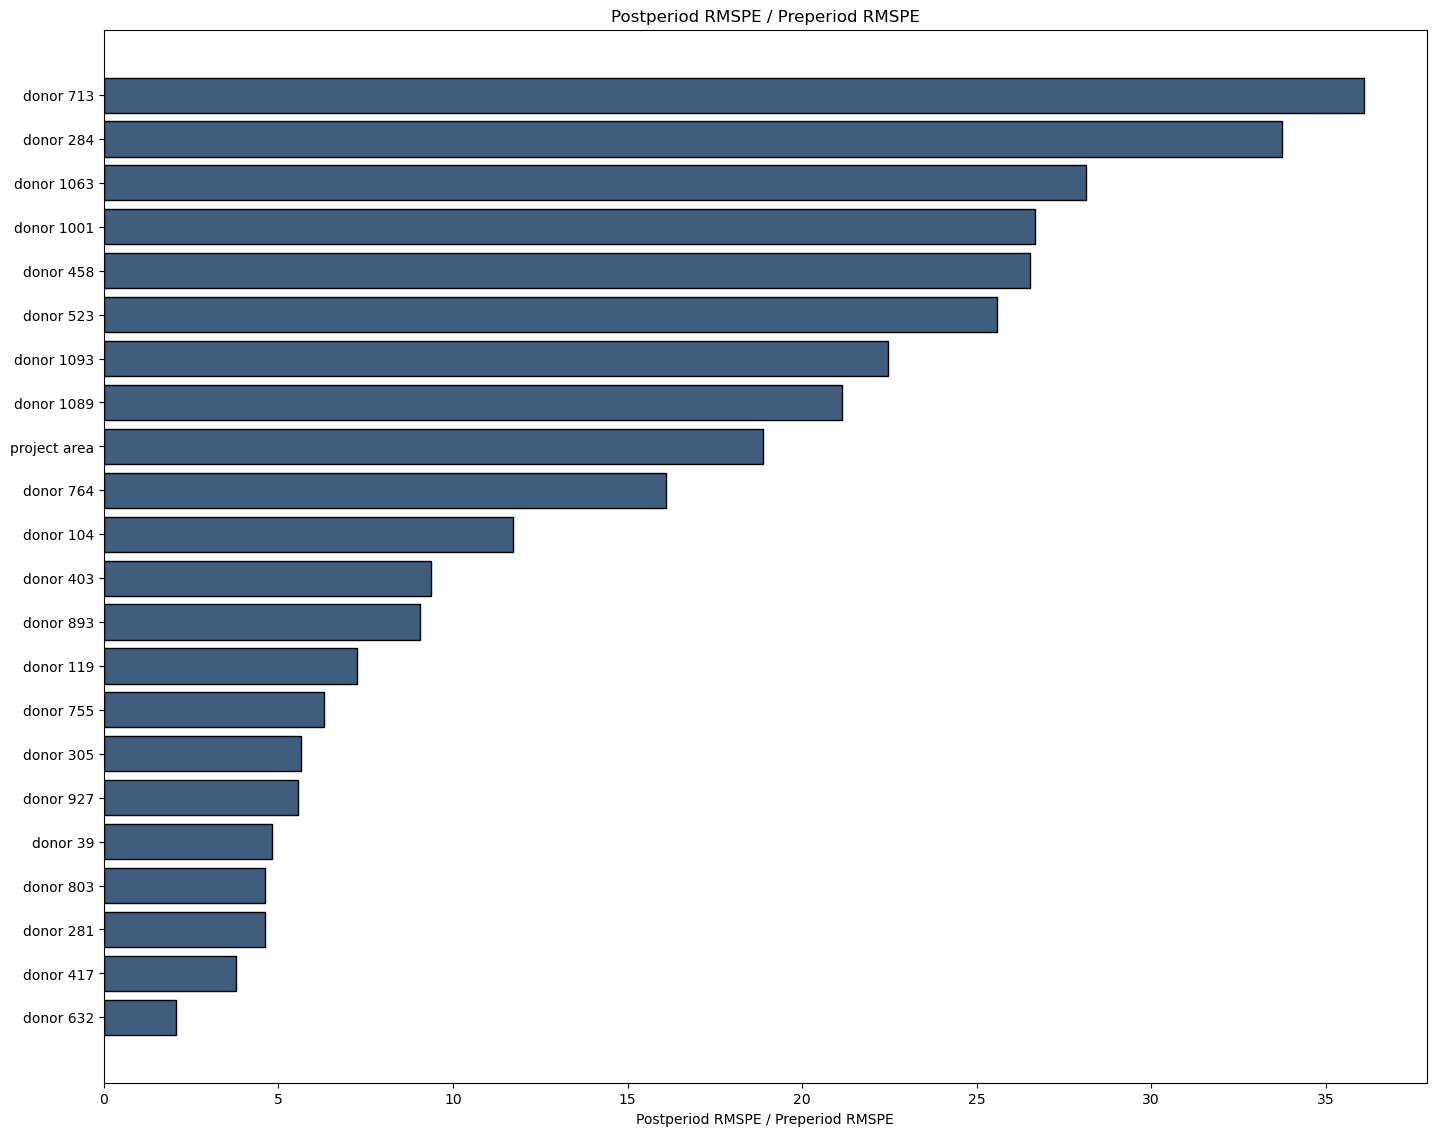

In [7]:
# Compute in-space placebos
PSCM_model.in_space_placebo(15)

# Visualize
PSCM_model.plot(['rmspe ratio'])

### Plot the placebo scatter plot and 95% confidence intervals

    year  donor 104     donor 281  donor 284  donor 403  donor 755  \
0   2001     -36.27 -4.500000e-01      -1.08       2.70     -43.83   
1   2002     -13.86  2.160000e+00       7.20      15.30     -35.37   
2   2003     -11.25 -1.350000e+00       7.20      54.09     -31.05   
3   2004     -26.01 -1.018297e-12       1.08    -187.11     -29.43   
4   2005      58.23  6.588000e+01      23.58     -25.74     -14.13   
5   2006      51.03  5.463000e+01      19.80      17.19     -71.37   
6   2007     -25.11  8.460000e+00      14.31     -73.98    -113.85   
7   2008     -17.82  3.780000e+00      10.44       2.97     -24.84   
8   2009       6.84  6.300000e-01       6.21       8.01      -0.09   
9   2010     -40.86  8.280000e+00      20.70       0.45    -104.58   
10  2011      25.29  2.061000e+01      13.77       0.36      -8.64   
11  2012      37.53  5.220000e+00      32.40       8.64      -0.45   
12  2013      72.00  1.971000e+01     -51.30      17.01     102.87   
13  2014      16.29 

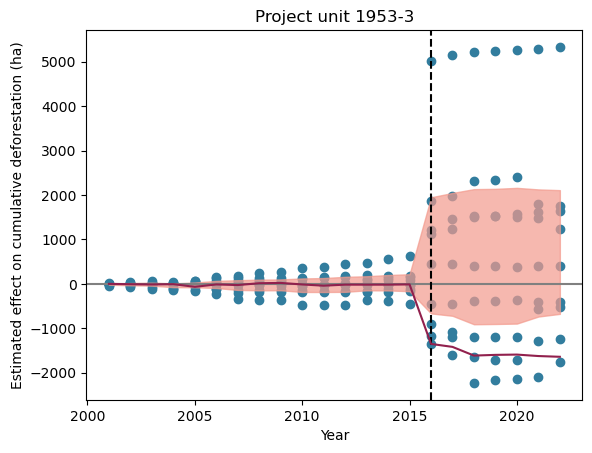

In [8]:
# Get the donor list from df_of_targer_instance
donor_list_rows = df_of_targer_instance[df_of_targer_instance['region'].str.contains('donor', na=False)]
donor_list = donor_list_rows['region'].unique()

# Obtain the pointwise placebo test results of the donors and convert them into a data frame
placebo_pointwise_df = pd.DataFrame(np.concatenate(PSCM_model.original_data.in_space_placebos, axis=1), columns=donor_list)

# Obtain the rmspe result
rmspe_df = PSCM_model.original_data.rmspe_df
project_rmspe = rmspe_df.loc[rmspe_df['unit']=='project area','pre_rmspe'][0]
# Perform the square operation on the pre_rmspe column to obtain the pre-REDD mspe
mspe_df = pd.DataFrame({'pre_mspe': rmspe_df['pre_rmspe']**2})
mspe_df = pd.concat([rmspe_df['unit'], mspe_df], axis=1)

# Excluded placebo tests with mspe exceeding five times that of the project
project_mspe = mspe_df.loc[mspe_df['unit']=='project area','pre_mspe'].iloc[0]
remain_donor_df = mspe_df[mspe_df['pre_mspe'] <= project_mspe * 5]

# Convert the 'unit' column of remain_donor_df the into a list and exclude the first entry
remain_donor_list = remain_donor_df['unit'].tolist()[1:]  # The first entry is assumed to be the project area, which is not needed here
# Select the corresponding columns from placebo_pointwise_df using the donor list
remain_placebo_pointwise_df = placebo_pointwise_df[remain_donor_list]
# Insert a 'year' column at the first position in the DataFrame, with a range from 2001 to 2022
remain_placebo_pointwise_df.insert(0, 'year', range(2001,2023))
print(remain_placebo_pointwise_df)

# Convert pointwise to a cumulative data frame, that is, calculate the cumulative value
remain_placebo_cumulative_df = remain_placebo_pointwise_df.copy()
remain_placebo_cumulative_df.iloc[:, 1:] = remain_placebo_pointwise_df.iloc[:, 1:].cumsum()  # Cumulatively sum all columns except the year column

# Calculate the mean and confidence interval of the donor column
data_values = remain_placebo_cumulative_df.drop('year', axis=1)  # Except the year column
mean_values = data_values.mean(axis=1)
ci_values = data_values.sem(axis=1) * 1.96  # 95% confidence interval

# Generate figure
# Draw a horizontal line at y = 0
plt.axhline(y=0, color='grey', linestyle='-')
# Draw a vertical line at x = start_year
plt.axvline(x=start_year, color='black', linestyle='--')

# Draw a scatter plot for the donors
columns = data_values.columns
for column in columns:
    plt.scatter(remain_placebo_cumulative_df['year'], remain_placebo_cumulative_df[column], label=column, color='#327D9E')

# Draw a line plot for the project
plt.plot(cumulative_deforest_df['year'], cumulative_deforest_df['cumulation difference'], label='Project', color='#91204D')

# Add the shadow of the confidence interval
plt.fill_between(remain_placebo_cumulative_df['year'], mean_values - ci_values, mean_values + ci_values, alpha=0.7, color='#F39A8D')

# Add the title and coordinate axis labels
plt.title(f'Project unit {project_unit}')
plt.xlabel('Year')
plt.ylabel('Estimated effect on cumulative deforestation (ha)')

plt.show()
plt.close()